# 📊 Análise de Transações de Clientes

Este notebook tem como objetivo explorar dados de transações de clientes e produtos, utilizando Python, pandas e matplotlib.

A análise inclui:

- produtos mais vendidos
- receita por categoria
- evolução das transações ao longo do tempo
- comportamento de compra dos clientes

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
clientes = pd.read_csv('../data/raw/clientes.csv', sep=';')
produtos = pd.read_csv('../data/raw/produtos.csv', sep=';')
transacoes = pd.read_csv('../data/raw/transacoes.csv', sep=';')
transacao_produto = pd.read_csv('../data/raw/transacao_produto.csv', sep=';')

In [46]:
clientes.head()


,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao
0,000dc0f6-e4f2-4a42-b8cd-b586ed1c709a,0,1,0,0,0,2,2025-11-13 12:03:56.114,2025-12-13 11:45:37.364
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697
2,001749bd-37b5-4b1e-8111-f9fbba90f530,0,0,0,0,0,50,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
3,0019bb9e-26d4-4ebf-8727-fc911ea28a92,0,0,0,0,0,2,2024-02-01 00:00:00.000,2024-02-01 00:00:00.000
4,0028dda2-334f-40bb-9582-475fb6719471,1,1,1,0,0,1100,2025-10-29 02:08:18.367,2026-02-24 04:49:02.551


In [47]:
produtos.head()

,IdProduto,DescNomeProduto,DescDescricaoProduto,DescCategoriaProduto
0,001 - Espada Longa,Espada Longa,Uma espada longa de aço.,espada
1,002 - Espada Curta,Espada Curta,Espada leve e rápida.,espada
2,003 - Armadura de Couro,Armadura de Couro,Armadura leve feita de couro.,armadura
3,004 - Armadura de Placas,Armadura de Placas,Armadura pesada de placas metálicas.,armadura
4,005 - Botas de Agilidade,Botas de Agilidade,Botas que aumentam a destreza.,botas


In [48]:
transacao_produto.head()

,idTransacaoProduto,IdTransacao,IdProduto,QtdeProduto,vlProduto
0,000026d0-4d4e-4fed-934a-9e5b26d9e379,d59d9859-8fb9-41cc-a296-be38c4dce8e4,5,1,1
1,00002f54-dd03-4b3f-ade0-22c3e61df8c2,519241fd-2676-49b2-8e74-0acc09a08f69,5,1,1
2,00006a7d-c83a-44ca-aad9-e8a2a2f1b64d,73993c42-d18f-4f51-82c4-25e13c29962c,11,1,50
3,0000991a-e6ae-4b9f-8747-c6cfe77890dd,db341350-16e4-49ea-96d4-c3e991e7c8c0,5,1,1
4,0000d145-c8b5-48fb-9ea3-d91eba3af306,7ee57139-6183-4cd6-8960-b5b14884aefb,5,1,1


In [49]:
transacoes.head()

,IdTransacao,IdCliente,DtCriacao,QtdePontos,DescSistemaOrigem
0,0000520a-a4e5-4977-b360-17be62fa0f2b,24782f0b-4683-4f35-976a-ea21d6714ba6,2025-09-17 12:28:41.864,1,twitch
1,000060e8-aa76-4286-a8d7-f30e6fa47edd,252a0923-3f79-45bb-b664-3040235c6c58,2024-07-23 12:49:49.874,1,twitch
2,000095de-3daa-4cfb-a0ae-e7b2c8bc3c9b,30f45a6d-ada5-4a17-8338-710e414eb6c6,2025-09-17 13:38:57.479,1,twitch
3,0000c010-a592-46f7-8b0b-6f841bee64ba,65662aff-44d6-4f06-b9d9-07445c6e5943,2025-10-03 12:23:39.779,1,twitch
4,0000dfbb-e14e-4ea7-a57f-60236869fffe,5f8fcbe0-6014-43f8-8b83-38cf2f4887b3,2024-02-20 13:21:45.613,1,twitch


In [50]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5080 entries, 0 to 5079
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   idCliente      5080 non-null   object
 1   flEmail        5080 non-null   int64 
 2   flTwitch       5080 non-null   int64 
 3   flYouTube      5080 non-null   int64 
 4   flBlueSky      5080 non-null   int64 
 5   flInstagram    5080 non-null   int64 
 6   qtdePontos     5080 non-null   int64 
 7   DtCriacao      5080 non-null   object
 8   DtAtualizacao  5080 non-null   object
dtypes: int64(6), object(3)
memory usage: 357.3+ KB


In [51]:
produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   IdProduto             118 non-null    object
 1   DescNomeProduto       118 non-null    object
 2   DescDescricaoProduto  77 non-null     object
 3   DescCategoriaProduto  118 non-null    object
dtypes: object(4)
memory usage: 3.8+ KB


In [52]:
transacao_produto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302787 entries, 0 to 302786
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   idTransacaoProduto  302787 non-null  object
 1   IdTransacao         302787 non-null  object
 2   IdProduto           302629 non-null  object
 3   QtdeProduto         302787 non-null  int64 
 4   vlProduto           302787 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.6+ MB


In [53]:
transacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302424 entries, 0 to 302423
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   IdTransacao        302424 non-null  object
 1   IdCliente          302424 non-null  object
 2   DtCriacao          302424 non-null  object
 3   QtdePontos         302424 non-null  int64 
 4   DescSistemaOrigem  302424 non-null  object
dtypes: int64(1), object(4)
memory usage: 11.5+ MB


In [54]:
df = transacao_produto.merge(transacoes, on='IdTransacao')
df = df.merge(produtos, on='IdProduto')

In [55]:
df.head()

,idTransacaoProduto,IdTransacao,IdProduto,QtdeProduto,vlProduto,IdCliente,DtCriacao,QtdePontos,DescSistemaOrigem,DescNomeProduto,DescDescricaoProduto,DescCategoriaProduto
0,000026d0-4d4e-4fed-934a-9e5b26d9e379,d59d9859-8fb9-41cc-a296-be38c4dce8e4,5,1,1,d063b285-d7c5-4cf3-a046-afd9b11ac3be,2024-04-26 13:32:14.589,1,twitch,ChatMessage,NaN,chat
1,00002f54-dd03-4b3f-ade0-22c3e61df8c2,519241fd-2676-49b2-8e74-0acc09a08f69,5,1,1,65662aff-44d6-4f06-b9d9-07445c6e5943,2025-01-15 13:14:31.708,1,twitch,ChatMessage,NaN,chat
2,00006a7d-c83a-44ca-aad9-e8a2a2f1b64d,73993c42-d18f-4f51-82c4-25e13c29962c,11,1,50,066c9fc6-f704-4165-a8f3-3d1968b0d4a3,2024-07-12 12:37:04.803,50,twitch,Lista de presença,NaN,present
3,0000991a-e6ae-4b9f-8747-c6cfe77890dd,db341350-16e4-49ea-96d4-c3e991e7c8c0,5,1,1,f19aaa00-f337-4174-ba14-a2a39dd6ebbf,2025-05-05 11:53:58.409,1,twitch,ChatMessage,NaN,chat
4,0000d145-c8b5-48fb-9ea3-d91eba3af306,7ee57139-6183-4cd6-8960-b5b14884aefb,5,1,1,17ac2f0f-5448-44de-b245-bb3b9592ab5d,2025-08-27 12:10:55.389,1,twitch,ChatMessage,NaN,chat


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302321 entries, 0 to 302320
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   idTransacaoProduto    302321 non-null  object
 1   IdTransacao           302321 non-null  object
 2   IdProduto             302321 non-null  object
 3   QtdeProduto           302321 non-null  int64 
 4   vlProduto             302321 non-null  int64 
 5   IdCliente             302321 non-null  object
 6   DtCriacao             302321 non-null  object
 7   QtdePontos            302321 non-null  int64 
 8   DescSistemaOrigem     302321 non-null  object
 9   DescNomeProduto       302321 non-null  object
 10  DescDescricaoProduto  60 non-null      object
 11  DescCategoriaProduto  302321 non-null  object
dtypes: int64(3), object(9)
memory usage: 27.7+ MB


In [57]:
df['DtCriacao'] = pd.to_datetime(df['DtCriacao'])

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302321 entries, 0 to 302320
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   idTransacaoProduto    302321 non-null  object        
 1   IdTransacao           302321 non-null  object        
 2   IdProduto             302321 non-null  object        
 3   QtdeProduto           302321 non-null  int64         
 4   vlProduto             302321 non-null  int64         
 5   IdCliente             302321 non-null  object        
 6   DtCriacao             302321 non-null  datetime64[ns]
 7   QtdePontos            302321 non-null  int64         
 8   DescSistemaOrigem     302321 non-null  object        
 9   DescNomeProduto       302321 non-null  object        
 10  DescDescricaoProduto  60 non-null      object        
 11  DescCategoriaProduto  302321 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 27

In [59]:
top_produtos = (
    df.groupby("DescNomeProduto")["QtdeProduto"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_produtos

DescNomeProduto
ChatMessage                                   249753
Lista de presença                              41257
Presença Streak                                 3118
Resgatar Ponei                                  1924
Troca de Pontos StreamElements                  1603
Churn_5pp                                       1582
Churn_2pp                                       1068
Churn_10pp                                      1056
Daily Loot                                       499
Venda de Item: 7 - Capacete de Ferro (400)       220
Name: QtdeProduto, dtype: int64

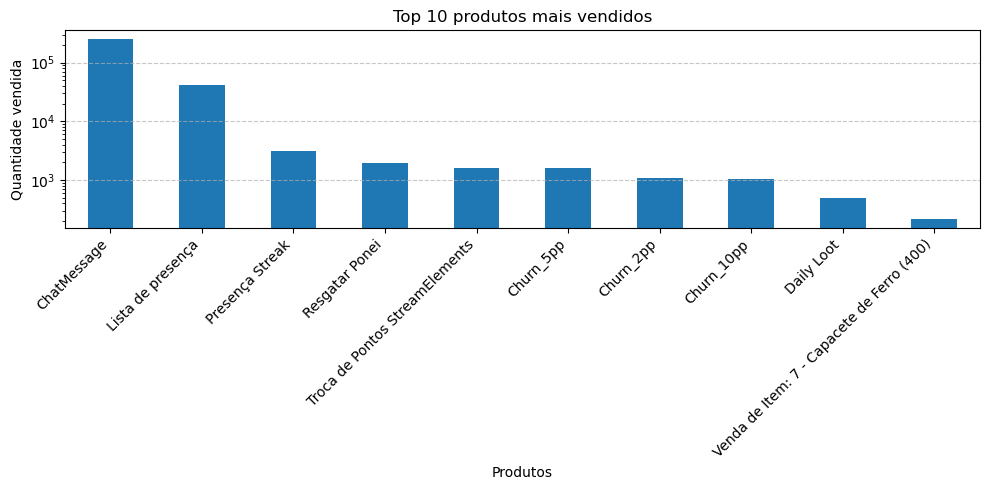

In [60]:
top_produtos.plot(kind="bar",figsize=(10,5))
plt.title("Top 10 produtos mais vendidos")
plt.ylabel("Quantidade vendida")
plt.xlabel("Produtos")

plt.yscale("log")

plt.xticks(rotation= 45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [61]:
receita_categoria = (
    df.groupby("DescCategoriaProduto")["vlProduto"]
    .sum()
    .sort_values(ascending=False)
)
receita_categoria

DescCategoriaProduto
present           2374850
ponei              690000
chat               249753
churn_model        196460
espada              19850
chapeu              19000
botas                7500
armadura             7000
cajado               5000
adaga                4800
lovers              -5026
rpg                -99831
streamelements   -1534000
Name: vlProduto, dtype: int64

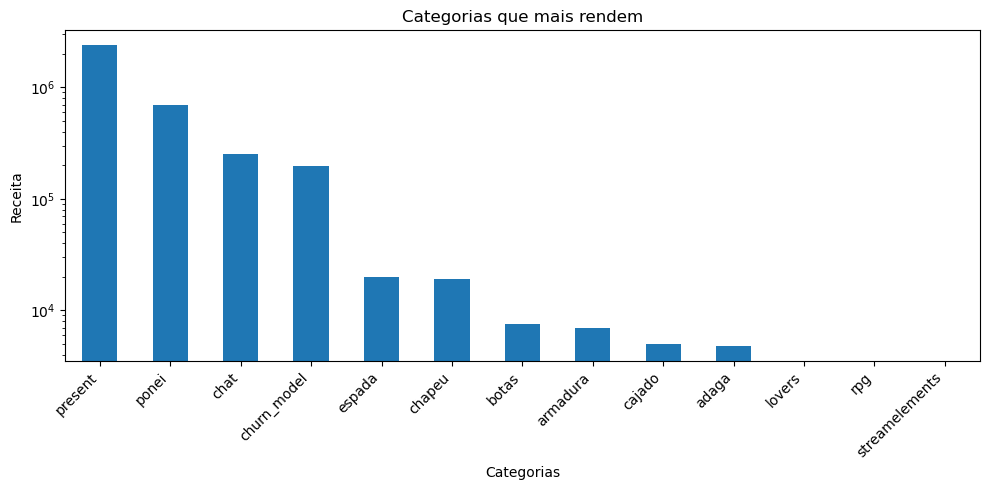

In [62]:
receita_categoria.plot(kind="bar", figsize=(10,5))
plt.title("Categorias que mais rendem")
plt.xlabel("Categorias")
plt.ylabel("Receita")

plt.yscale("log")

plt.xticks(rotation= 45, ha="right")

plt.tight_layout()
plt.show()

In [63]:
valor_medio_categoria = (
    df.groupby("DescCategoriaProduto")["vlProduto"]
    .mean()
    .sort_values(ascending= False)
)

valor_medio_categoria

DescCategoriaProduto
armadura          1750.000000
cajado            1666.666667
adaga             1600.000000
espada            1102.777778
botas              937.500000
chapeu             791.666667
ponei              358.627859
present             53.517746
churn_model         53.011333
chat                 1.000000
lovers             -48.796117
rpg               -125.731738
streamelements    -955.168120
Name: vlProduto, dtype: float64

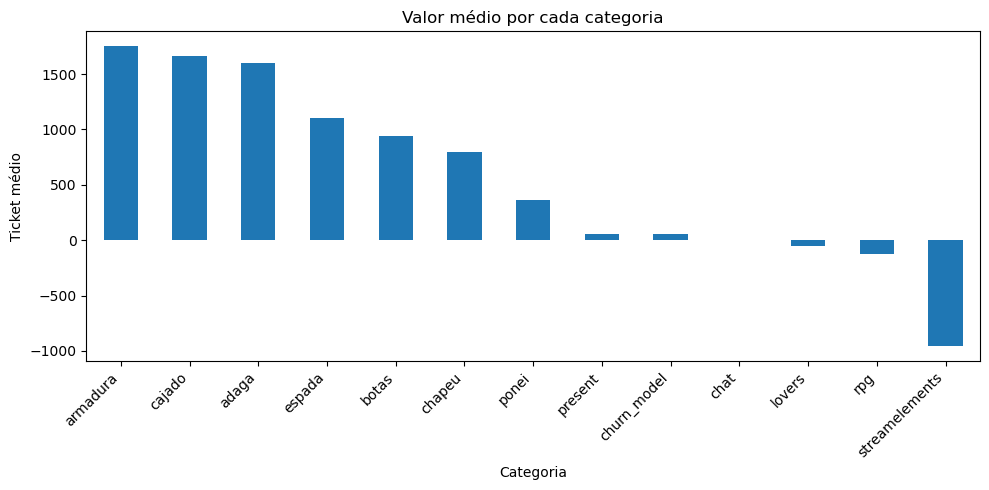

In [64]:
valor_medio_categoria.plot(kind="bar",figsize=(10,5))
plt.title("Valor médio por cada categoria")
plt.xlabel("Categoria")
plt.ylabel("Ticket médio")

plt.xticks(rotation= 45, ha="right")

plt.tight_layout()
plt.show()


In [65]:
receita = df[df["vlProduto"] > 0]
custo = df[df["vlProduto"] < 0]

In [66]:
receita_total = receita["vlProduto"].sum()
custo_total = custo["vlProduto"].sum()

In [67]:
df["mes"] = df["DtCriacao"].dt.to_period("M")

transacoes_mes = (
    df.groupby("mes")["IdTransacao"]
    .nunique()
)
transacoes_mes

mes
2024-01     1409
2024-02    19543
2024-03    24696
2024-04    25371
2024-05    17060
2024-06    16652
2024-07    13766
2024-08    10727
2024-09    11502
2024-10     7764
2024-11     5495
2024-12     6902
2025-01    11074
2025-02    10687
2025-03     7782
2025-04     6461
2025-05     6669
2025-06     6696
2025-07     5599
2025-08    15146
2025-09    16951
2025-10    17418
2025-11     7962
2025-12     9836
2026-01     6303
2026-02    10501
2026-03     2001
Freq: M, Name: IdTransacao, dtype: int64

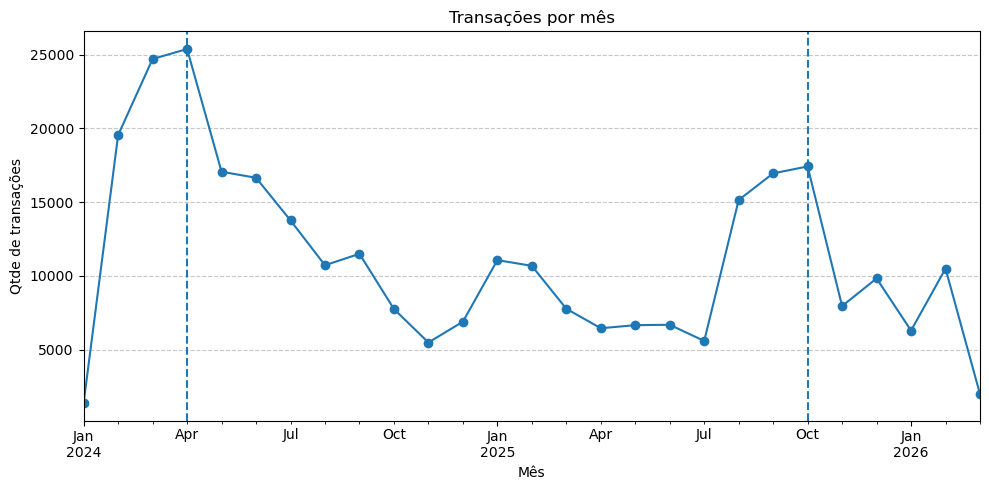

In [68]:
transacoes_mes.plot(figsize=(10,5), marker="o")
plt.title("Transações por mês")
plt.xlabel("Mês")
plt.ylabel("Qtde de transações")

plt.axvline("2024-04", linestyle="--")
plt.axvline("2025-10", linestyle="--")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [69]:
uso_categoria = (
    df.groupby("DescCategoriaProduto")["QtdeProduto"]
    .sum()
    .sort_values(ascending= False)
)

top_3_percentual = (uso_categoria.head(3).sum() / uso_categoria.sum()) * 100

top_3_percentual

np.float64(98.515815970442)

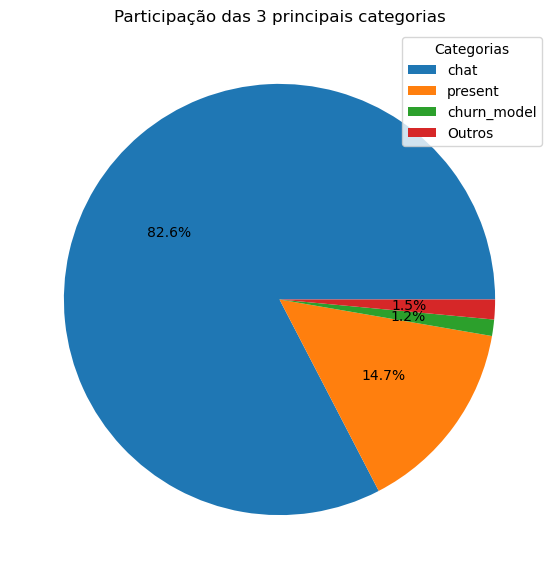

In [70]:
top3 = uso_categoria.head(3)
outros = uso_categoria.iloc[3:].sum()

pizza = top3.copy()
pizza["Outros"] = outros

pizza.plot(
    kind="pie",
    figsize=(7,7),
    autopct="%1.1f%%",
    labels=None
)

plt.title("Participação das 3 principais categorias")
plt.ylabel("")

plt.legend(pizza.index, title="Categorias", loc="best")

plt.show()

## Principais Insights

1. Volume de uso ≠ geração de receita

Embora ChatMessage seja o produto mais utilizado na plataforma, apresentando o maior volume de transações, ele não é o principal gerador de receita.

Ao analisar a receita por categoria, observou-se que present e ponei geram mais pontos do que chat, indicando que produtos com menor volume de uso podem ter maior impacto financeiro.

Esse comportamento sugere que a plataforma possui uma dinâmica onde algumas funcionalidades são utilizadas com maior frequência para engajamento, enquanto outras concentram maior valor monetário por transação

2. Receita concentrada em poucas categorias

A análise da distribuição de uso mostra que apenas três categorias representam aproximadamente 98,5% de todo o volume de interações na plataforma.

Esse resultado indica uma forte concentração do comportamento dos usuários em poucos tipos de produtos, enquanto as demais categorias possuem participação marginal.

3. Itens premium apresentam alto valor médio

Ao analisar o valor médio das transações por categoria, observou-se que itens relacionados a equipamentos e itens especiais apresentam valores significativamente mais altos.

Isso sugere a existência de produtos com perfil premium, caracterizados por menor frequência de compra, mas maior valor financeiro por transação.

4. Lançamentos de cursos geram picos de atividade

A análise temporal das transações mostrou picos claros de atividade em determinados períodos.

Com base no contexto do negócio, esses picos coincidem com datas de lançamento de novos cursos, indicando que os lançamentos impactam diretamente o nível de atividade da comunidade.

Esse comportamento sugere que eventos relacionados a novos conteúdos funcionam como importantes gatilhos de engajamento dos usuários.

## Conclusão

A análise revelou que o comportamento da plataforma apresenta forte concentração de uso em poucas categorias, enquanto a geração de receita está associada a produtos de maior valor unitário. Além disso, eventos externos, como lançamentos de cursos, demonstram impacto significativo na atividade dos usuários.